In [ ]:
import torch

import numpy as np

from sbi.analysis import pairplot
from sbi.inference import NPE,NLE
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
from torch.distributions import Normal, Independent,InverseGamma
from torch.distributions.multivariate_normal import MultivariateNormal

import rpy2.robjects as robjects
import numpy as np

import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

In [38]:
# load parameter from R
robjects.r('load("SpainPROV_CerebrovascularDiseases.Rdata")')

Rs = robjects.r('as.matrix(Rs)')

Rs_numpy = np.array(Rs)

print("Rs_numpy shape:", Rs_numpy.shape)


Rs_numpy shape: (47, 47)


In [39]:

eigenvalues, eigenvectors = np.linalg.eig(Rs_numpy)

Q = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T  # Q = V * D * V.T


In [40]:
mu = np.zeros(Rs_numpy.shape[0], dtype=np.float32)

In [41]:
num_dim = 47  
def simulator(theta, n=100):

    log_risk = theta[:47]
    lam = np.exp(log_risk)
    obs = np.random.poisson(lam=lam, size=(n, 47)).astype(np.float32)
    
    return obs

prior = MultivariateNormal(
        loc=torch.tensor(mu, dtype=torch.float),
        covariance_matrix=torch.tensor(Q, dtype=torch.float)
    )




In [42]:
prior, num_parameters, prior_returns_numpy = process_prior(prior)

# Check simulator, returns PyTorch simulator able to simulate batches.
simulator = process_simulator(simulator, prior, prior_returns_numpy)

# Consistency check after making ready for sbi.
check_sbi_inputs(simulator, prior)


In [46]:
inference = NPE(prior=prior)
# get test data
num_simulations = 500
theta = prior.sample((num_simulations,))
x = simulator(theta)

#theta.shape torch.Size([500, 47])
#x.shape torch.Size([500, 100, 47])


In [47]:
x = x.reshape(num_simulations, -1)
inference = inference.append_simulations(theta, x)
density_estimator = inference.train()

 Neural network successfully converged after 99 epochs.

In [18]:
posterior = inference.build_posterior(density_estimator)

In [49]:

theta_obs = prior.sample((50,))  # torch.Size([50, 47])

x_obs = simulator(theta_obs)    # [50, 47, 100]

x_obs_flat = x_obs.view(50, -1)#[1, 235000]


In [ ]:
samples = posterior.sample_batched(
    sample_shape=(1000,),
    x=x_obs_flat  # [50, 4700]
)

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

In [56]:

mean = samples.mean(dim=0)      # shape = [50, 47]
std  = samples.std(dim=0)       # shape = [50, 47]


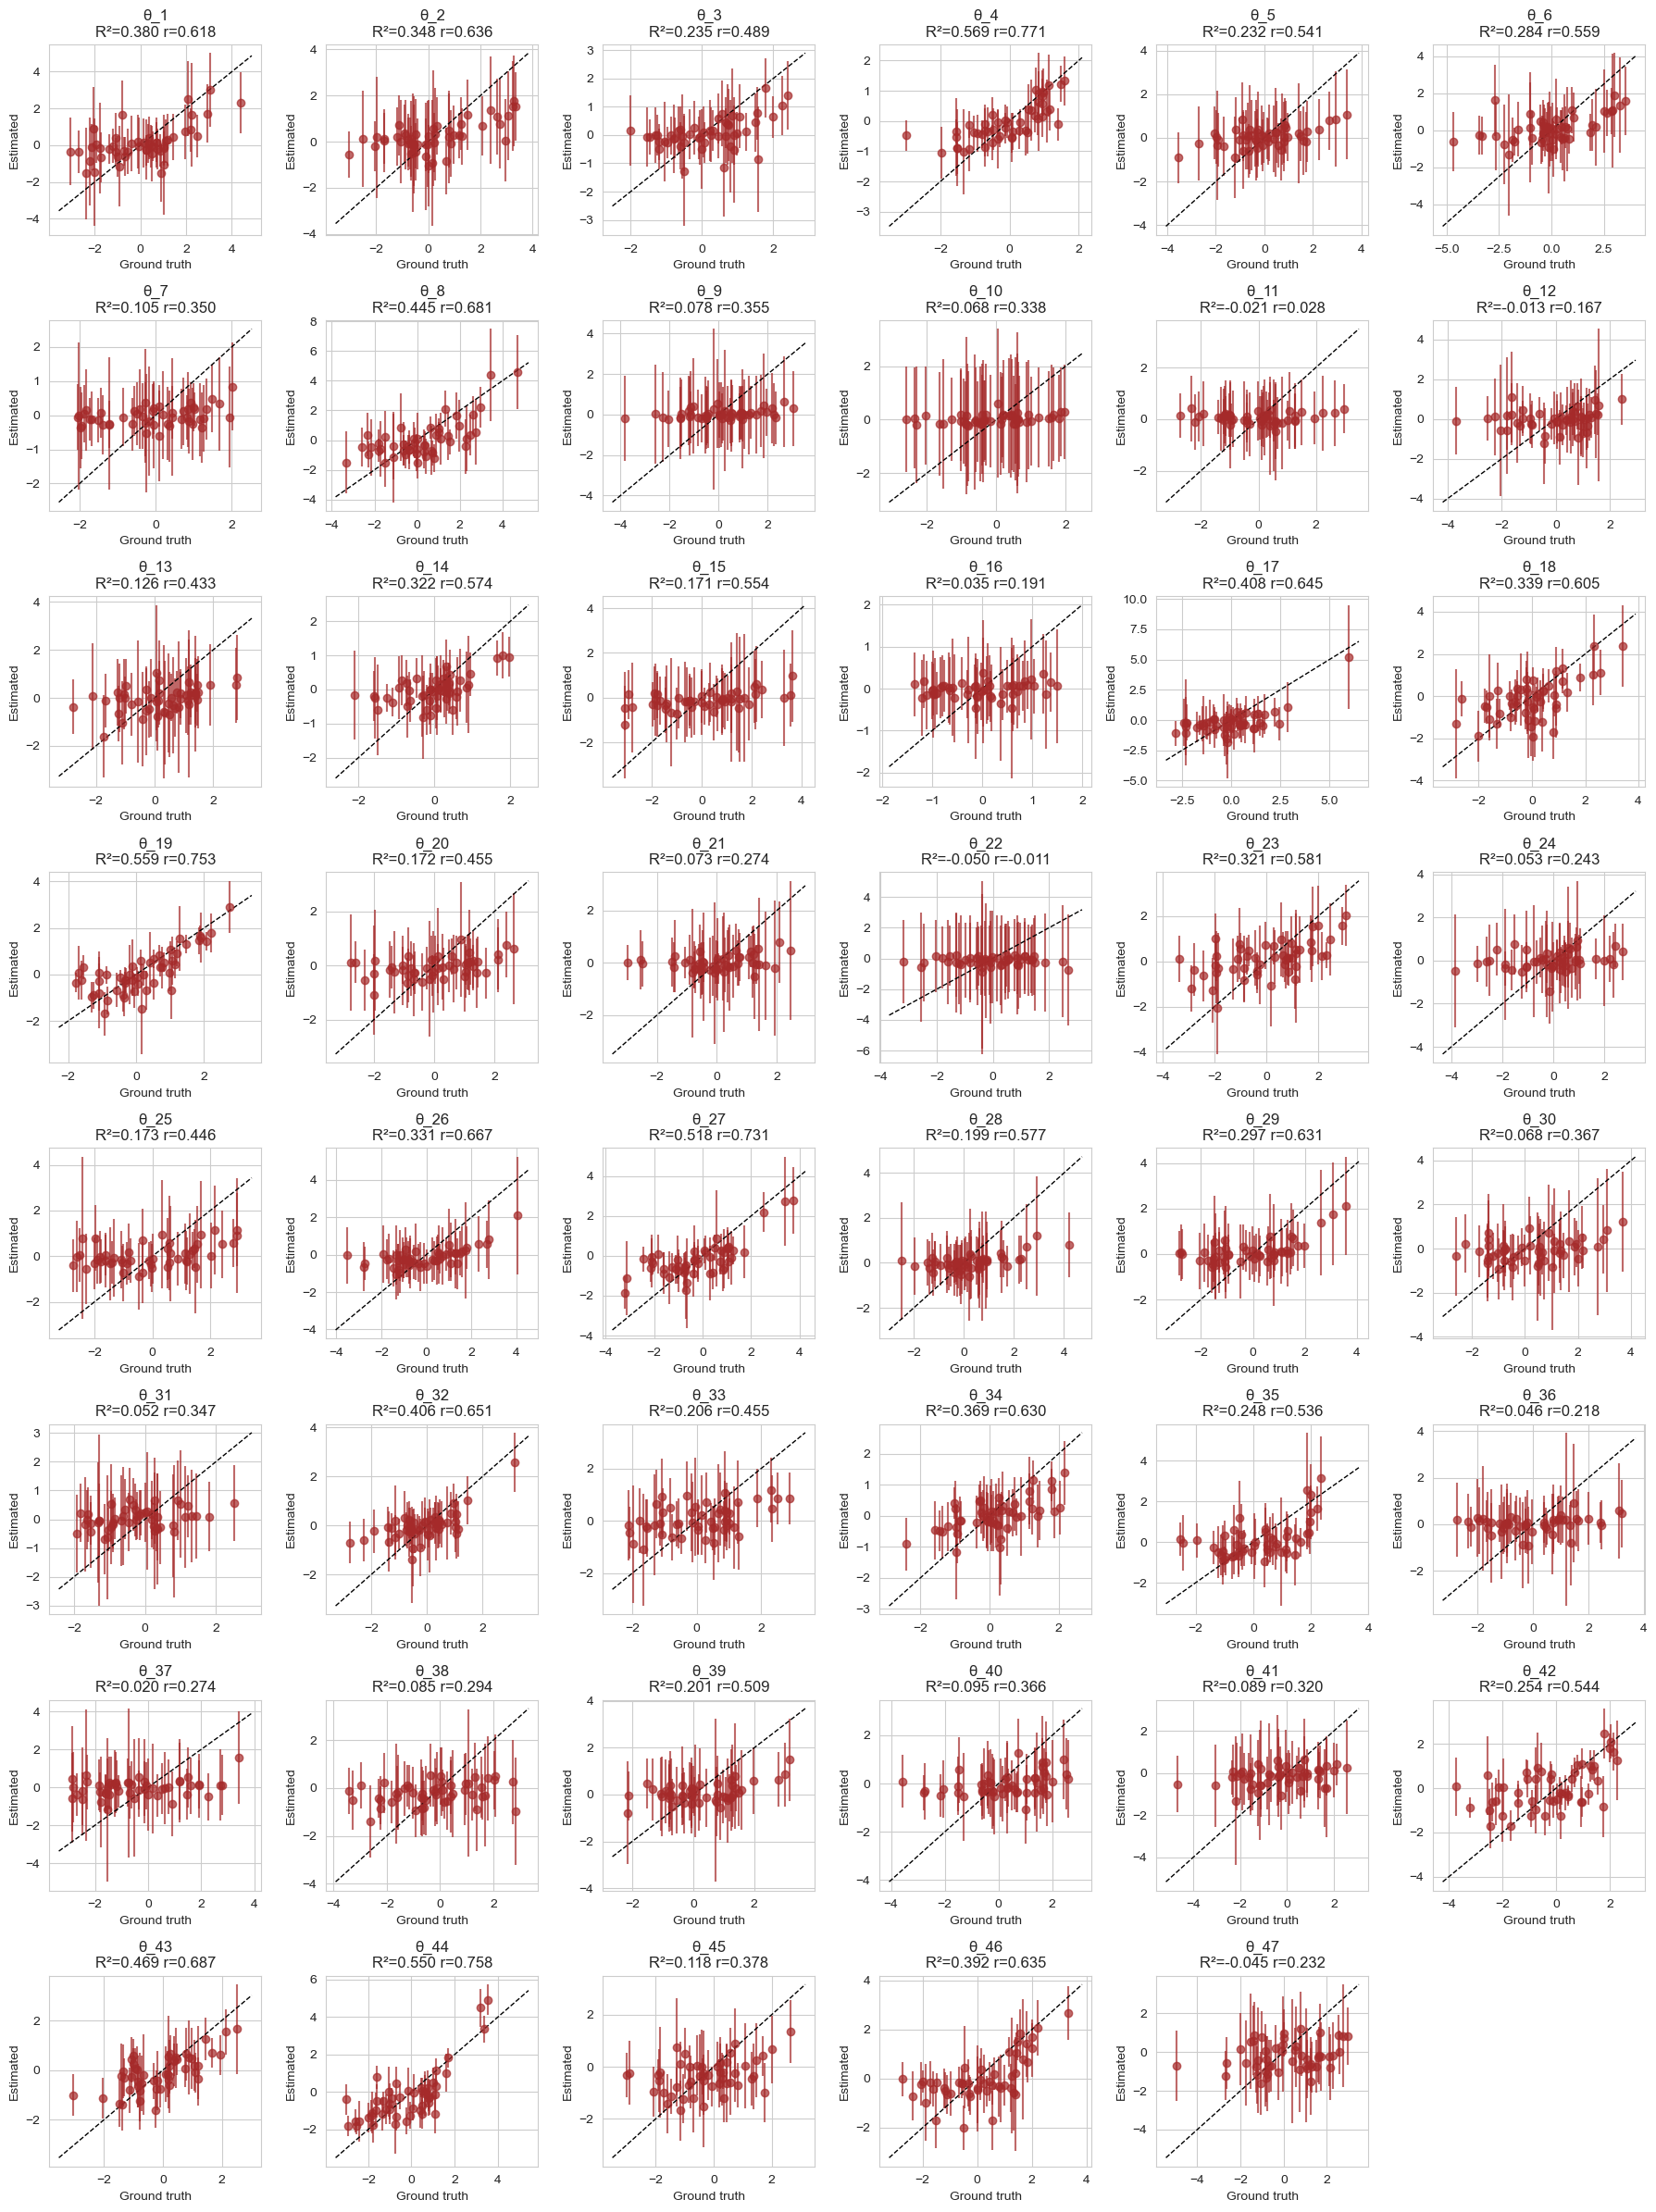

In [ ]:


mean_np = mean.numpy()         # [50, 47]
std_np  = std.numpy()          # [50, 47]
theta_obs_np = theta_obs.numpy()  # [50, 47]

num_params = 47
ncols = 6
nrows = (num_params + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 24))
axes = axes.flatten()

for i in range(num_params):
    ax = axes[i]
    
    ax.errorbar(
        theta_obs_np[:, i],     
        mean_np[:, i],           
        yerr=std_np[:, i],   
        fmt='o', color='brown', ecolor='brown', alpha=0.7
    )
    
    min_val = min(theta_obs_np[:, i].min(), mean_np[:, i].min()) - 0.5
    max_val = max(theta_obs_np[:, i].max(), mean_np[:, i].max()) + 0.5
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
    
    # R^2 and pearson r
    r2 = r2_score(theta_obs_np[:, i], mean_np[:, i])
    r, _ = pearsonr(theta_obs_np[:, i], mean_np[:, i])
    
    ax.set_title(f'θ_{i+1}\nR²={r2:.3f} r={r:.3f}')
    ax.set_xlabel('Ground truth')
    ax.set_ylabel('Estimated')

for i in range(num_params, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()
